In [25]:
from pathlib import Path
import html
import re
import unicodedata

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

In [ ]:
# ============================
# RUTAS
# ============================

from pathlib import Path

BASE = Path(
    r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13"
)

RUTA_PROCESADOS = (
    BASE
    / "01_data"
    / "02_processed"
    / "rrss"
    / "forocoches"
)

RUTA_COMENTARIOS = (
    RUTA_PROCESADOS
    / "forocoches_comentarios_anuales.csv"
)

RUTA_TABLAS = (
    BASE
    / "03_outputs"
    / "tables"
    / "rrss"
    / "forocoches"
)

RUTA_GRAFICOS = (
    BASE
    / "03_outputs"
    / "figures"
    / "rrss"
    / "forocoches"
)

RUTA_WORDCLOUD = (
    RUTA_GRAFICOS
    / "wordcloud"
)

RUTA_MODELOS = (
    BASE
    / "01_data"
    / "02_processed"
    / "modelos"
    / "forocoches"
)

RUTA_DICCIONARIOS = (
    BASE
    / "scripts"
    / "diccionarios"
)

for carpeta in [
    RUTA_PROCESADOS,
    RUTA_TABLAS,
    RUTA_GRAFICOS,
    RUTA_WORDCLOUD,
    RUTA_MODELOS
]:
    carpeta.mkdir(
        parents=True,
        exist_ok=True
    )

print("Comentarios:", RUTA_COMENTARIOS)
print("Existe:", RUTA_COMENTARIOS.exists())
print("Tablas:", RUTA_TABLAS)
print("Gráficos:", RUTA_GRAFICOS)

Ruta del proyecto: c:\Users\herre\OneDrive\Desktop\IT ACADEMY\ESPECIALIDAD\EJERCICICIOS\SPRINT 13
Archivo de comentarios: c:\Users\herre\OneDrive\Desktop\IT ACADEMY\ESPECIALIDAD\EJERCICICIOS\SPRINT 13\RRSS\FOROCOCHES\PROCESADOS\forocoches_comentarios_anuales.csv
Existe: True


In [28]:
# ============================
# CARGA DEL DATASET
# ============================

df = pd.read_csv(
    RUTA_COMENTARIOS,
    encoding="utf-8"
)

print(f"Comentarios: {len(df):,}")
display(df.head())

Comentarios: 7,689


,tema,anio_objetivo,id_hilo,titulo_hilo,url_hilo,pagina,id_mensaje,numero_mensaje,usuario_hash,fecha_comentario,anio_comentario,es_mensaje_inicial,texto_original,texto_sin_citas,contiene_cita,texto_propio_vacio,pertenece_anio_objetivo,lote_extraccion,revision_tematica,subtema_validado,nota_validacion_tematica
0,inmigracion,2016,4730394,Un asunto delicado el tema INMIGRACIÓN y delincuencia. ¿Qué eliges?,https://forocoches.com/foro/showthread.php?t=4730394,1,217029942,1,adf0a55d9756d742,2016-01-07 10:01:00,2016,True,"Es lo que están acostumbrados en sus países, si no mirad lo que pasa en Guatemala, El Salvador, Honduras...\nY países musulmanes, con guerras civi...","Es lo que están acostumbrados en sus países, si no mirad lo que pasa en Guatemala, El Salvador, Honduras...\nY países musulmanes, con guerras civi...",False,False,True,NaN,NaN,NaN,NaN
1,inmigracion,2016,4730394,Un asunto delicado el tema INMIGRACIÓN y delincuencia. ¿Qué eliges?,https://forocoches.com/foro/showthread.php?t=4730394,1,217029965,2,ed380416ab43785f,2016-01-07 10:01:00,2016,False,"Ya te lo dice esta pole, cada vecino en su parcela","Ya te lo dice esta pole, cada vecino en su parcela",False,False,True,NaN,NaN,NaN,NaN
2,inmigracion,2016,4730394,Un asunto delicado el tema INMIGRACIÓN y delincuencia. ¿Qué eliges?,https://forocoches.com/foro/showthread.php?t=4730394,1,217029968,3,0b812141842fc387,2016-01-07 10:01:00,2016,False,Lo que hay que hacer es dar una patada en el culo a todo invasor parásito que pise Europa.,Lo que hay que hacer es dar una patada en el culo a todo invasor parásito que pise Europa.,False,False,True,NaN,NaN,NaN,NaN
3,inmigracion,2016,4730394,Un asunto delicado el tema INMIGRACIÓN y delincuencia. ¿Qué eliges?,https://forocoches.com/foro/showthread.php?t=4730394,1,217029973,4,f11f0d951c6afdb6,2016-01-07 10:01:00,2016,False,Menudo ladrillo a estas horas,Menudo ladrillo a estas horas,False,False,True,NaN,NaN,NaN,NaN
4,inmigracion,2016,4730394,Un asunto delicado el tema INMIGRACIÓN y delincuencia. ¿Qué eliges?,https://forocoches.com/foro/showthread.php?t=4730394,1,217030090,5,48ba2627a46ec5d1,2016-01-07 10:05:00,2016,False,La segunda y cuarta opción son lo mismo.,La segunda y cuarta opción son lo mismo.,False,False,True,NaN,NaN,NaN,NaN


In [ ]:
ANIOS_ANALISIS = [
    2015,
    2016,
    2019,
    2023
]

anios_encontrados = sorted(
    df["anio_objetivo"]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

print("Años encontrados:", anios_encontrados)

assert anios_encontrados == ANIOS_ANALISIS, (
    f"Años inesperados: {anios_encontrados}"
)

In [29]:
# ============================
# INFORMACIÓN GENERAL
# ============================

print("Dimensiones:", df.shape)

display(df.info())

display(df.describe(include="all").T)

Dimensiones: (7689, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7689 entries, 0 to 7688
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   tema                      7689 non-null   object
 1   anio_objetivo             7689 non-null   int64 
 2   id_hilo                   7689 non-null   int64 
 3   titulo_hilo               7689 non-null   object
 4   url_hilo                  7689 non-null   object
 5   pagina                    7689 non-null   int64 
 6   id_mensaje                7689 non-null   int64 
 7   numero_mensaje            7689 non-null   int64 
 8   usuario_hash              7671 non-null   object
 9   fecha_comentario          7689 non-null   object
 10  anio_comentario           7689 non-null   int64 
 11  es_mensaje_inicial        7689 non-null   bool  
 12  texto_original            7520 non-null   object
 13  texto_sin_citas           7420 non-null   object
 14  

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tema,7689,2,inmigracion,5309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anio_objetivo,7689.0,NaN,NaN,NaN,2018.088828,3.140864,2015.0,2016.0,2016.0,2023.0,2023.0
id_hilo,7689.0,NaN,NaN,NaN,6532897.292236,2052739.242545,4085624.0,4840201.0,5149331.0,9415175.0,9810719.0
titulo_hilo,7689,81,"REGUGIADO SIRIO: ""ESPERABA MÁS de ESPAÑA""",1553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
url_hilo,7689,81,https://forocoches.com/foro/showthread.php?t=5149331,1553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pagina,7689.0,NaN,NaN,NaN,8.563662,11.78002,1.0,1.0,3.0,9.0,52.0
id_mensaje,7689.0,NaN,NaN,NaN,305490225.951359,99977887.964513,182899139.0,223253580.0,240204051.0,445985530.0,466453839.0
numero_mensaje,7689.0,NaN,NaN,NaN,241.529588,353.816696,1.0,29.0,89.0,266.0,1553.0
usuario_hash,7671,4686,a9e4f7d8522c1899,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_comentario,7689,5413,2016-09-23 13:27:00,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# ============================
# VALORES NULOS
# ============================

nulos = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("nulos")
)

nulos["porcentaje"] = (
    nulos["nulos"] / len(df) * 100
).round(2)

display(nulos)

,nulos,porcentaje
nota_validacion_tematica,7640,99.36
subtema_validado,7640,99.36
pertenece_anio_objetivo,5081,66.08
revision_tematica,5027,65.38
lote_extraccion,2608,33.92
texto_sin_citas,269,3.50
texto_original,169,2.20
usuario_hash,18,0.23
url_hilo,0,0.00
tema,0,0.00


In [31]:
# ============================
# COMENTARIOS DUPLICADOS
# ============================

duplicados = df.duplicated().sum()

print(f"Filas duplicadas: {duplicados:,}")

duplicados_texto = df.duplicated(subset=["texto_sin_citas"]).sum()

print(f"Comentarios duplicados por texto: {duplicados_texto:,}")

Filas duplicadas: 0
Comentarios duplicados por texto: 383


tema
inmigracion    5309
lgtbi          2380
Name: count, dtype: int64

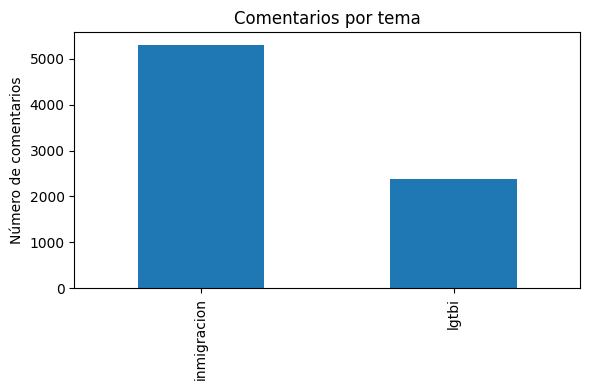

In [32]:
# ============================
# DISTRIBUCIÓN POR TEMA
# ============================

display(df["tema"].value_counts())

(
    df["tema"]
      .value_counts()
      .plot.bar(figsize=(6,4))

)

plt.title("Comentarios por tema")
plt.xlabel("")
plt.ylabel("Número de comentarios")
plt.tight_layout()
plt.show()

anio_objetivo
2015    1575
2016    2850
2019    1303
2023    1961
Name: count, dtype: int64

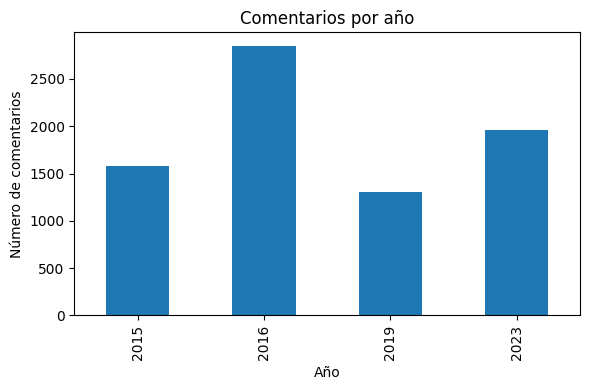

In [33]:
# ============================
# DISTRIBUCIÓN POR AÑO
# ============================

display(df["anio_objetivo"].value_counts().sort_index())

(
    df["anio_objetivo"]
      .value_counts()
      .sort_index()
      .plot.bar(figsize=(6,4))
)

plt.title("Comentarios por año")
plt.xlabel("Año")
plt.ylabel("Número de comentarios")
plt.tight_layout()
plt.show()

In [34]:
df["texto"] = df["texto_sin_citas"]

In [35]:
# ============================
# LIMPIEZA DEL TEXTO
# ============================

def limpiar_texto(texto):

    if pd.isna(texto):
        return ""

    texto = html.unescape(texto)

    texto = texto.lower()

    texto = unicodedata.normalize("NFKC", texto)

    texto = re.sub(r"https?://\S+", " ", texto)

    texto = re.sub(r"www\.\S+", " ", texto)

    texto = re.sub(r"\S+@\S+", " ", texto)

    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()

In [36]:
# ============================
# CREAR TEXTO LIMPIO
# ============================

df["texto_limpio"] = df["texto"].apply(limpiar_texto)

display(
    df[
        [
            "texto",
            "texto_limpio"
        ]
    ].head(10)
)

,texto,texto_limpio
0,"Es lo que están acostumbrados en sus países, si no mirad lo que pasa en Guatemala, El Salvador, Honduras...\nY países musulmanes, con guerras civi...","es lo que están acostumbrados en sus países, si no mirad lo que pasa en guatemala, el salvador, honduras... y países musulmanes, con guerras civil..."
1,"Ya te lo dice esta pole, cada vecino en su parcela","ya te lo dice esta pole, cada vecino en su parcela"
2,Lo que hay que hacer es dar una patada en el culo a todo invasor parásito que pise Europa.,lo que hay que hacer es dar una patada en el culo a todo invasor parásito que pise europa.
3,Menudo ladrillo a estas horas,menudo ladrillo a estas horas
4,La segunda y cuarta opción son lo mismo.,la segunda y cuarta opción son lo mismo.
5,"qué libertad?\nes que acaso tú puedes ir al país que quieras y quedarte cuanto quieras y disfrutar de todos sus servicios como uno más? No, eso só...","qué libertad? es que acaso tú puedes ir al país que quieras y quedarte cuanto quieras y disfrutar de todos sus servicios como uno más? no, eso sól..."
6,"Esta claro que hay que endurecer las leyes. Pero, partiendo de eso, ¿no crees que la solución estaría en la educación, integración y sobre todo el...","esta claro que hay que endurecer las leyes. pero, partiendo de eso, ¿no crees que la solución estaría en la educación, integración y sobre todo el..."
7,"Es un dilema bastante grande shur, muy delicado todo.","es un dilema bastante grande shur, muy delicado todo."
8,Que se vayan todos y de paso de lleven a los gitanos.,que se vayan todos y de paso de lleven a los gitanos.
9,El origen del problema: Afganistán.\nTodo empezó con la guerra de Afganistán de 1978. Un antes una\nrevolución espontánea\ncontra un régimen tota...,el origen del problema: afganistán. todo empezó con la guerra de afganistán de 1978. un antes una revolución espontánea contra un régimen totalmen...


In [37]:
# ============================
# ELIMINAR COMENTARIOS VACÍOS
# ============================

antes = len(df)

df = df[
    df["texto_limpio"].str.len() > 0
].copy()

despues = len(df)

print(f"Comentarios eliminados: {antes - despues:,}")

print(f"Comentarios restantes: {despues:,}")

Comentarios eliminados: 289
Comentarios restantes: 7,400


In [ ]:
# ============================
# GUARDAR DATASET NLP
# ============================

df.to_csv(
    RUTA_NLP,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset guardado en:")
print(RUTA_NLP)

Dataset guardado en:
c:\Users\herre\OneDrive\Desktop\IT ACADEMY\ESPECIALIDAD\EJERCICICIOS\SPRINT 13\RRSS\FOROCOCHES\PROCESADOS\forocoches_comentarios_nlp.csv


# NLP
### BLOQUE 1 - Estadísticas generales

In [39]:
# ============================
# RESUMEN DEL DATASET
# ============================

print("=" * 50)
print("RESUMEN DEL DATASET")
print("=" * 50)

print(f"Comentarios: {len(df):,}")
print(f"Hilos: {df['id_hilo'].nunique():,}")
print(f"Usuarios: {df['usuario_hash'].nunique():,}")
print(f"Años: {df['anio_objetivo'].nunique()}")
print(f"Temas: {df['tema'].nunique()}")

print("\nAños disponibles:")
print(sorted(df["anio_objetivo"].unique()))

print("\nTemas:")
print(df["tema"].unique())

RESUMEN DEL DATASET
Comentarios: 7,400
Hilos: 81
Usuarios: 4,542
Años: 4
Temas: 2

Años disponibles:
[np.int64(2015), np.int64(2016), np.int64(2019), np.int64(2023)]

Temas:
['inmigracion' 'lgtbi']


,anio_objetivo,comentarios
0,2015,1446
1,2016,2760
2,2019,1272
3,2023,1922


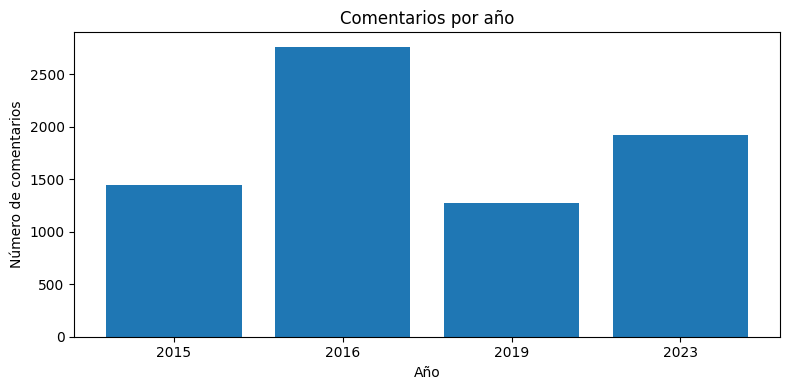

In [40]:
# ============================
# COMENTARIOS POR AÑO
# ============================

comentarios_anio = (
    df.groupby("anio_objetivo")
      .size()
      .reset_index(name="comentarios")
)

display(comentarios_anio)

plt.figure(figsize=(8,4))

plt.bar(
    comentarios_anio["anio_objetivo"].astype(str),
    comentarios_anio["comentarios"]
)

plt.title("Comentarios por año")
plt.xlabel("Año")
plt.ylabel("Número de comentarios")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "01_comentarios_por_anio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,tema,comentarios
0,inmigracion,5175
1,lgtbi,2225


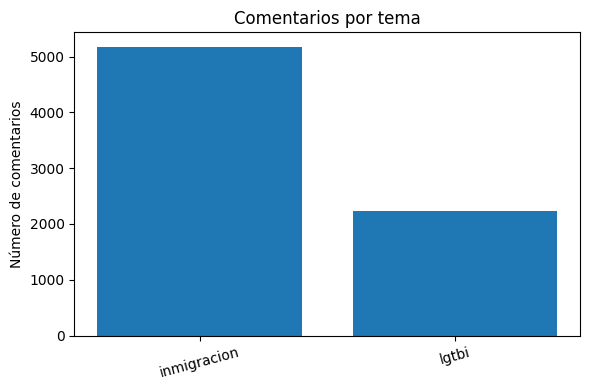

In [41]:
# ============================
# COMENTARIOS POR TEMA
# ============================

comentarios_tema = (
    df.groupby("tema")
      .size()
      .reset_index(name="comentarios")
      .sort_values("comentarios", ascending=False)
)

display(comentarios_tema)

plt.figure(figsize=(6,4))

plt.bar(
    comentarios_tema["tema"],
    comentarios_tema["comentarios"]
)

plt.title("Comentarios por tema")
plt.xlabel("")
plt.ylabel("Número de comentarios")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "02_comentarios_por_tema.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,titulo_hilo,comentarios
47,"REGUGIADO SIRIO: ""ESPERABA MÁS de ESPAÑA""",1510
23,Interior traslada a Huesca a 200 migrantes llegados desde Canarias,513
66,Un hombre de 52 años se transforma en una niña de seis,512
21,Estoy a favor de la inmigración ilegal,299
31,La obsesión homófoba de VOX empieza a ser enfermiza,265
35,"Los EXTRANJEROS APORTAN el 10 % a la Seguridad Social y SOLO RECIBEN el 0,9 %",221
70,Valencia. nmigrantes sin papeles empadronados durante un año cobrarán hasta 532 euros,207
75,¿Estarias a favor de expulsar a todos los musulmanes de España?,202
44,"Progres, asumidlo: El Nacionalismo Identitario tomará las riendas de Europa",181
51,"Refugees vienen, ven que España está hecho mierdas y se van desengañados...",179


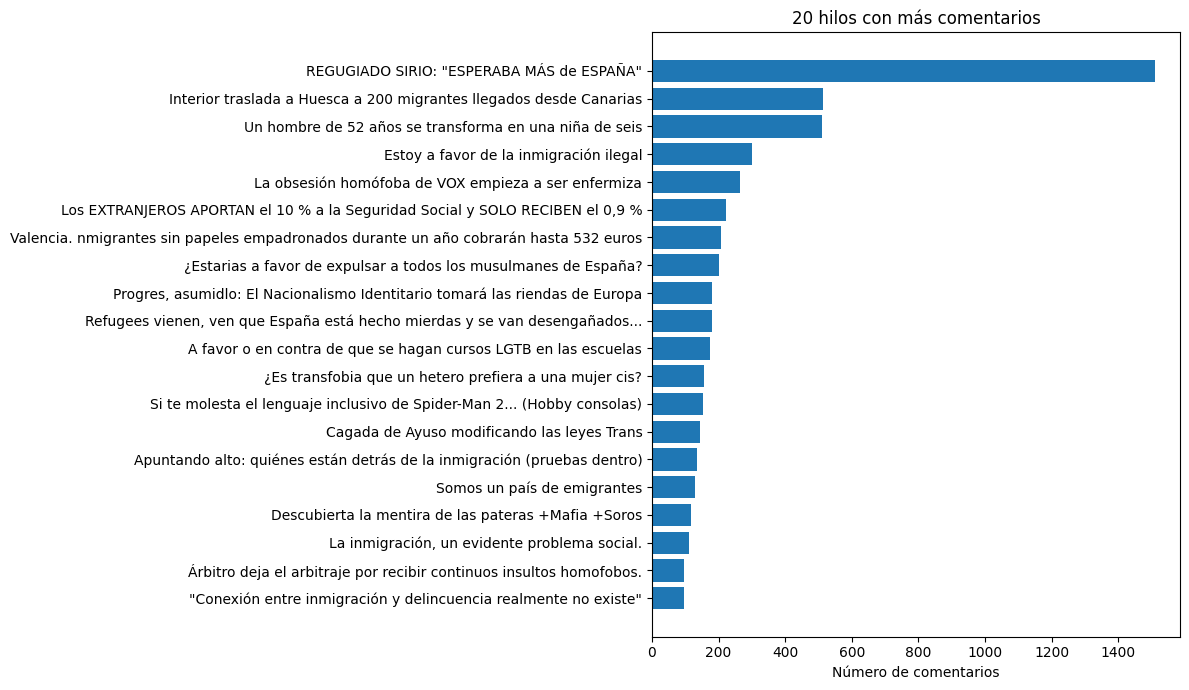

In [42]:
# ============================
# HILOS CON MÁS COMENTARIOS
# ============================

top_hilos = (
    df.groupby("titulo_hilo")
      .size()
      .reset_index(name="comentarios")
      .sort_values("comentarios", ascending=False)
      .head(20)
)

display(top_hilos)

plt.figure(figsize=(12,7))

plt.barh(
    top_hilos["titulo_hilo"],
    top_hilos["comentarios"]
)

plt.title("20 hilos con más comentarios")
plt.xlabel("Número de comentarios")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "04_top_hilos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
# ============================
# EXPORTAR TABLAS
# ============================

comentarios_anio.to_csv(
    RUTA_TABLAS / "comentarios_por_anio.csv",
    index=False,
    encoding="utf-8-sig"
)

comentarios_tema.to_csv(
    RUTA_TABLAS / "comentarios_por_tema.csv",
    index=False,
    encoding="utf-8-sig"
)

top_hilos.to_csv(
    RUTA_TABLAS / "top_hilos.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tablas exportadas correctamente.")

Tablas exportadas correctamente.


### Bloque 2. Aplicar el diccionario RRSS

In [ ]:
# ============================
# IMPORTAR DICCIONARIO RRSS
# ============================

import importlib.util

ARCHIVO_DICCIONARIO_RRSS = (
    RUTA_DICCIONARIOS
    / "diccionario_rrss.py"
)

print("Diccionario:", ARCHIVO_DICCIONARIO_RRSS)
print("Existe:", ARCHIVO_DICCIONARIO_RRSS.exists())

if not ARCHIVO_DICCIONARIO_RRSS.exists():
    raise FileNotFoundError(
        f"No se encuentra: {ARCHIVO_DICCIONARIO_RRSS}"
    )

spec = importlib.util.spec_from_file_location(
    "diccionario_rrss",
    ARCHIVO_DICCIONARIO_RRSS
)

modulo_diccionario_rrss = (
    importlib.util.module_from_spec(spec)
)

spec.loader.exec_module(
    modulo_diccionario_rrss
)

analizar_comentario_rrss = (
    modulo_diccionario_rrss
    .analizar_comentario_rrss
)

print("Diccionario cargado correctamente.")

In [46]:
# ============================
# ANÁLISIS DEL DICCIONARIO
# ============================

resultado = (
    df["texto_limpio"]
    .apply(analizar_comentario_rrss)
    .apply(pd.Series)
)

df = pd.concat(
    [df, resultado],
    axis=1
)

print("Columnas añadidas:")
print(resultado.columns.tolist())

Columnas añadidas:
['nivel_xenofobia_rrss', 'nivel_lgtbifobia_rrss', 'terminos_xenofobia_rrss', 'terminos_lgtbifobia_rrss', 'count_xeno_neutro_rrss', 'count_xeno_conflicto_rrss', 'count_xeno_hostilidad_rrss', 'count_xeno_violencia_rrss', 'count_lgtbi_neutro_rrss', 'count_lgtbi_conflicto_rrss', 'count_lgtbi_hostilidad_rrss', 'count_lgtbi_violencia_rrss']


In [47]:
# ============================
# COMPROBACIÓN
# ============================

display(
    df[
        [
            "texto_limpio",
            "nivel_xenofobia_rrss",
            "nivel_lgtbifobia_rrss"
        ]
    ].sample(15, random_state=42)
)

,texto_limpio,nivel_xenofobia_rrss,nivel_lgtbifobia_rrss
4910,"por culpa de los progres como tu parguela. votas morado y te quejas de que vengan moros, lo tuyo tiene un nombre.",hostilidad_explicita,sin_mencion
5283,"y porque no se fiscaliza el patrinomio o bienes que tienen en su país de origen. si se hiciera, muchos irían fuera. al pobre españolito sí se lo c...",sin_mencion,sin_mencion
7602,"que una mujer viole a otra mujer no es violencia de genero,jaque mate",sin_mencion,sin_mencion
174,"sí, cualquier persona tiene ese derecho pero el país donde vá tambien tiene el derecho de aceptarlo o no ¿no crees?",sin_mencion,sin_mencion
2082,"otro que mezcla churras con merinas..a ver si te crees que todos los mariquitas quieren operarse para ser mujer. algunos son muy ""machos"" y lo qui...",sin_mencion,sin_mencion
2523,le habrán felicitado todos los violadores que han salido antes de la cárcel gracias a su ley.,sin_mencion,sin_mencion
4678,pues ya tarda en marcharse para alemania y ya de paso que devuelva todas las ayudas que percibió en españa. que cierre la puerta al salir.,sin_mencion,sin_mencion
1769,si realmente te crees que sólo hay 27.000 extranjeros pensionistas es que vives en los mundos de yupi. trabajo en sanidad y hay cientos de miles d...,neutro,sin_mencion
2306,hasta elespanol.com he leído,sin_mencion,sin_mencion
4214,el problema es que en españa se les da mucho cuando no se les debería dar nada y tener mayor control del que entra y si pueden entrar o no. el paí...,neutro,violencia_discriminacion


,nivel,comentarios
0,sin_mencion,6193
1,neutro,581
2,marco_conflictivo,343
3,hostilidad_explicita,276
4,violencia_discriminacion,7


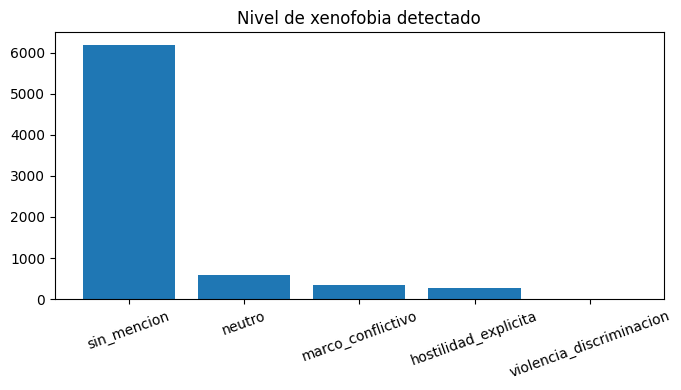

In [48]:
# ============================
# NIVELES DE XENOFOBIA
# ============================

niveles_xeno = (
    df["nivel_xenofobia_rrss"]
      .value_counts()
      .reset_index()
)

niveles_xeno.columns = [
    "nivel",
    "comentarios"
]

display(niveles_xeno)

plt.figure(figsize=(7,4))

plt.bar(
    niveles_xeno["nivel"],
    niveles_xeno["comentarios"]
)

plt.title("Nivel de xenofobia detectado")
plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS /
    "05_niveles_xenofobia.png",
    dpi=300
)

plt.show()

,nivel,comentarios
0,sin_mencion,6925
1,neutro,314
2,hostilidad_explicita,81
3,violencia_discriminacion,55
4,marco_conflictivo,25


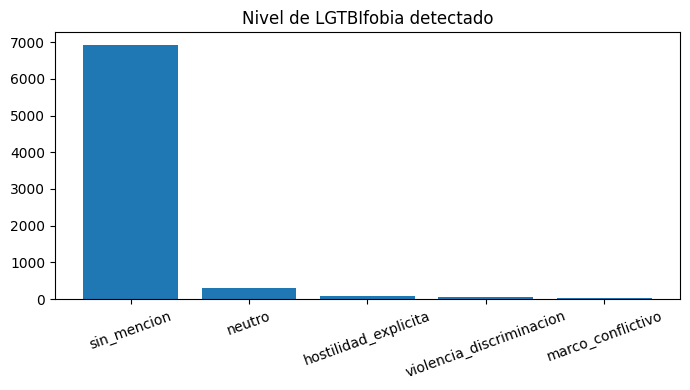

In [49]:
# ============================
# NIVELES LGTBIFOBIA
# ============================

niveles_lgtbi = (
    df["nivel_lgtbifobia_rrss"]
      .value_counts()
      .reset_index()
)

niveles_lgtbi.columns = [
    "nivel",
    "comentarios"
]

display(niveles_lgtbi)

plt.figure(figsize=(7,4))

plt.bar(
    niveles_lgtbi["nivel"],
    niveles_lgtbi["comentarios"]
)

plt.title("Nivel de LGTBIfobia detectado")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS /
    "06_niveles_lgtbifobia.png",
    dpi=300
)

plt.show()

### Bloque 3. Frecuencia de palabras

In [50]:
# ============================
# STOPWORDS EN ESPAÑOL
# ============================

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords_es = {
    "a", "al", "algo", "algunas", "algunos", "ante", "antes",
    "como", "con", "contra", "cual", "cuando", "de", "del",
    "desde", "donde", "durante", "e", "el", "ella", "ellas",
    "ellos", "en", "entre", "era", "erais", "eran", "eras",
    "eres", "es", "esa", "esas", "ese", "eso", "esos", "esta",
    "estaba", "estaban", "estado", "estamos", "estan", "estar",
    "estas", "este", "esto", "estos", "fue", "fueron", "ha",
    "han", "hasta", "hay", "la", "las", "le", "les", "lo",
    "los", "más", "me", "mi", "mis", "mucho", "muy", "no",
    "nos", "o", "os", "otra", "otras", "otro", "otros", "para",
    "pero", "por", "porque", "que", "qué", "se", "sea", "ser",
    "si", "sí", "sin", "sobre", "son", "su", "sus", "también",
    "te", "tiene", "tienen", "todo", "todos", "tu", "tus",
    "un", "una", "uno", "unos", "y", "ya", "yo", "nada", 
    "pues", "está", "estan", "están", "quien", "etc"
    "mas", "más", "aquí", "solo", "años",
    "ver", "así", "mismo", "bien", "ahora",
    "hace", "vida", "van", "menos", "vez",
    "mejor", "tener", "puede", "hacer", "luego", "parece",
    "hecho", "cada", "decir", "mundo",
    "cosas", "claro", "siempre", "igual",
    "creo", "dice", "muchos", "nadie", "toda", "tanto",
    "verdad", "poco", "tan", "dia",
    "día", "vaya", "shur", "hilo", "cosa"
}

print(f"Stopwords definidas: {len(stopwords_es)}")

Stopwords definidas: 151


In [51]:
# ============================
# FRECUENCIA DE PALABRAS
# ============================

from collections import Counter
import unicodedata

def quitar_tildes(texto):
    return "".join(
        caracter
        for caracter in unicodedata.normalize("NFD", str(texto))
        if unicodedata.category(caracter) != "Mn"
    )

texto_completo = " ".join(
    df["texto_limpio"].dropna().astype(str)
)

# Normalizamos el texto para unificar país/pais, más/mas, etc.
texto_frecuencias = quitar_tildes(texto_completo.lower())

# Normalizamos también las stopwords
stopwords_sin_tildes = {
    quitar_tildes(palabra.lower())
    for palabra in stopwords_es
}

palabras = re.findall(
    r"\b[a-zñ]{3,}\b",
    texto_frecuencias
)

palabras_filtradas = [
    palabra
    for palabra in palabras
    if palabra not in stopwords_sin_tildes
]

frecuencia_palabras = Counter(palabras_filtradas)

top_palabras = pd.DataFrame(
    frecuencia_palabras.most_common(30),
    columns=["palabra", "frecuencia"]
)

display(top_palabras)

,palabra,frecuencia
0,pais,785
1,gente,591
2,espana,570
3,inmigrantes,361
4,puta,357
5,mierda,322
6,inmigracion,304
7,paises,265
8,espanoles,265
9,problema,261


In [52]:
# ============================
# EXPORTAR TABLA
# ============================

top_palabras.to_csv(
    RUTA_TABLAS / "07_frecuencia_palabras.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tabla exportada.")

Tabla exportada.


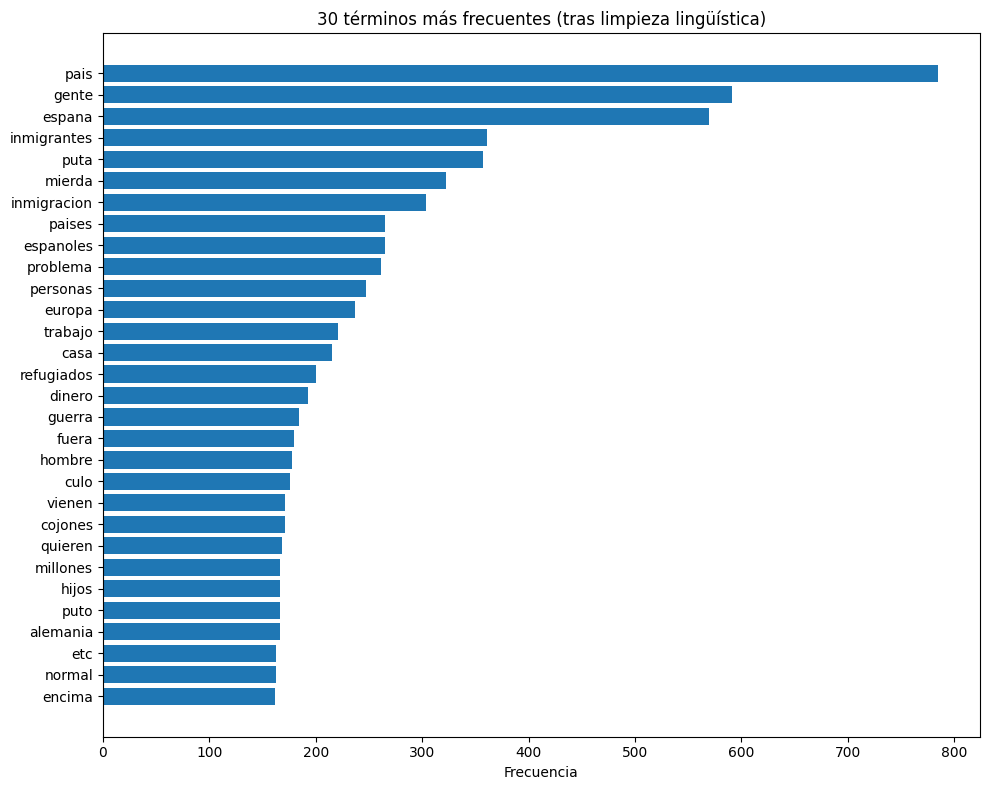

In [53]:
# ============================
# GRÁFICO
# ============================

plt.figure(figsize=(10,8))

plt.barh(
    top_palabras["palabra"],
    top_palabras["frecuencia"]
)

plt.gca().invert_yaxis()

plt.title("30 términos más frecuentes (tras limpieza lingüística)")
plt.xlabel("Frecuencia")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "07_frecuencia_palabras.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
frecuencias_completas = (
    pd.DataFrame(
        frecuencia_palabras.items(),
        columns=["palabra", "frecuencia"]
    )
    .sort_values("frecuencia", ascending=False)
)

frecuencias_completas.to_csv(
    RUTA_TABLAS / "07_frecuencia_palabras_completa.csv",
    index=False,
    encoding="utf-8-sig"
)

### Bloque 4. WordCloud

In [55]:
!pip install wordcloud

In [56]:
# ============================
# IMPORTAR WORDCLOUD
# ============================

from wordcloud import WordCloud

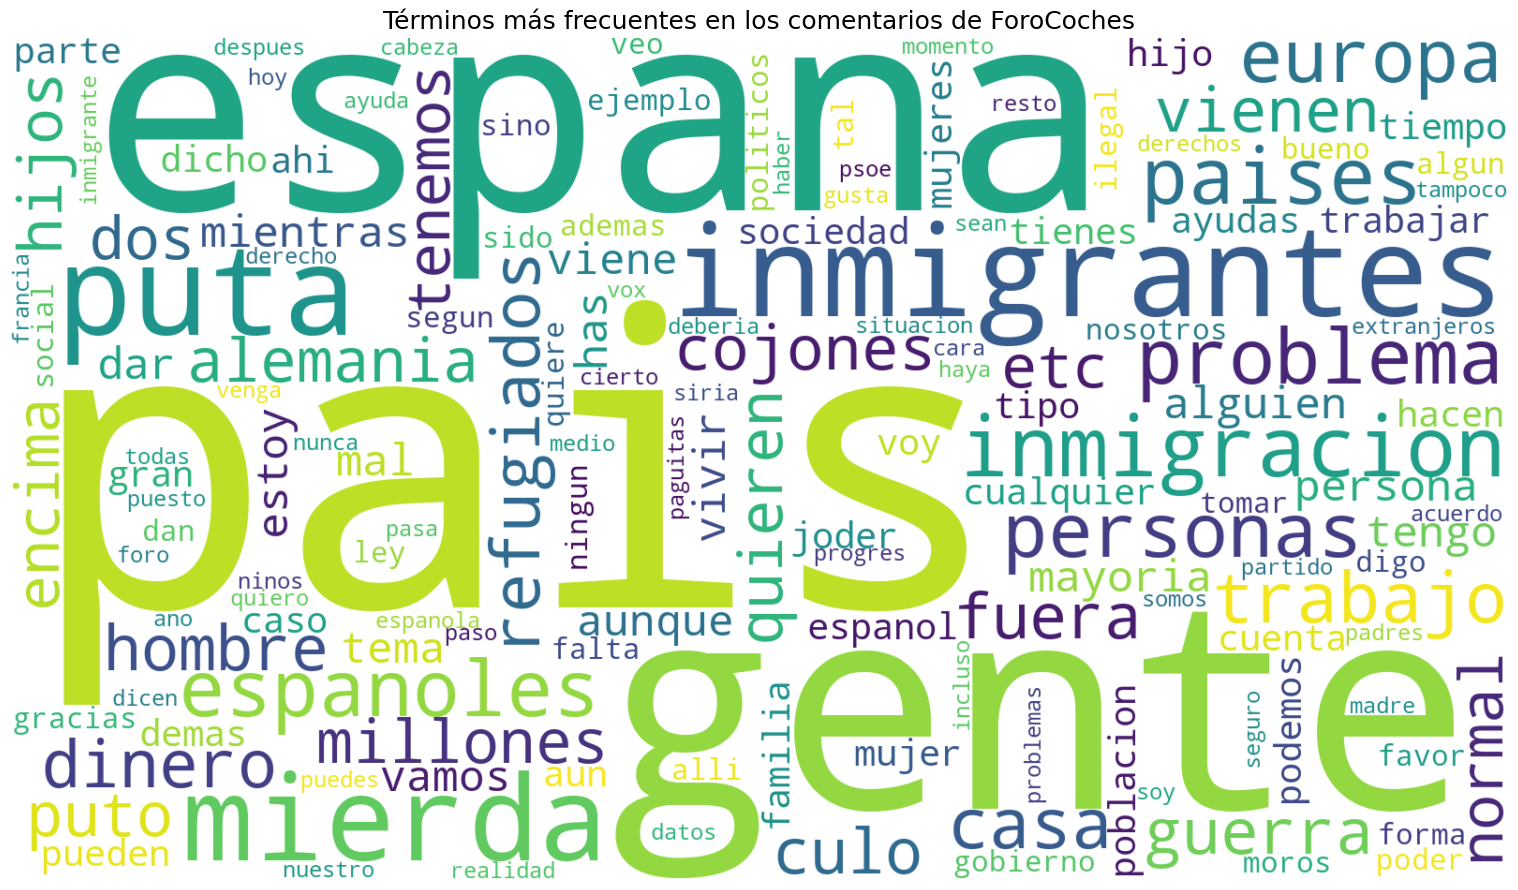

In [57]:
# ============================
# WORDCLOUD GENERAL
# ============================

wordcloud = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    max_words=150,
    collocations=False
).generate_from_frequencies(frecuencia_palabras)

plt.figure(figsize=(16, 9))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Términos más frecuentes en los comentarios de ForoCoches",
    fontsize=18
)

plt.tight_layout()

plt.savefig(
    RUTA_WORDCLOUD / "08_wordcloud_general.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
# ============================
# EXPORTAR DATOS WORDCLOUD
# ============================

tabla_wordcloud = (
    pd.DataFrame(
        frecuencia_palabras.items(),
        columns=["palabra", "frecuencia"]
    )
    .sort_values("frecuencia", ascending=False)
    .head(150)
)

tabla_wordcloud.to_csv(
    RUTA_TABLAS / "08_wordcloud_terminos.csv",
    index=False,
    encoding="utf-8-sig"
)

print("WordCloud y tabla exportadas correctamente.")

WordCloud y tabla exportadas correctamente.


### Bloque 5. Sentimiento

In [59]:
%pip install transformers torch sentencepiece tqdm

Note: you may need to restart the kernel to use updated packages.


In [60]:
# ============================
# MODELO DE SENTIMIENTO
# ============================

import torch

from transformers import pipeline
from tqdm.auto import tqdm

MODELO_SENTIMIENTO = (
    "pysentimiento/robertuito-sentiment-analysis"
)

dispositivo = 0 if torch.cuda.is_available() else -1

clasificador_sentimiento = pipeline(
    task="text-classification",
    model=MODELO_SENTIMIENTO,
    tokenizer=MODELO_SENTIMIENTO,
    device=dispositivo
)

print("Modelo cargado correctamente.")

if dispositivo == 0:
    print("Procesamiento con GPU.")
else:
    print("Procesamiento con CPU.")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11731.58it/s]


Modelo cargado correctamente.
Procesamiento con CPU.


In [61]:
# ============================
# PREPARAR TEXTOS
# ============================

textos_sentimiento = (
    df["texto_limpio"]
    .fillna("")
    .astype(str)
    .str.strip()
    .tolist()
)

print(f"Textos preparados: {len(textos_sentimiento)}")

Textos preparados: 7400


In [62]:
# ============================
# ANALIZAR SENTIMIENTO
# ============================

from tqdm.auto import tqdm

textos_sentimiento = (
    df["texto_limpio"]
    .fillna("")
    .astype(str)
    .tolist()
)

resultados = []

BATCH_SIZE = 32

for i in tqdm(range(0, len(textos_sentimiento), BATCH_SIZE)):

    lote = textos_sentimiento[i:i+BATCH_SIZE]

    predicciones = clasificador_sentimiento(
        lote,
        truncation=True,
        max_length=128,
        batch_size=BATCH_SIZE
    )

    resultados.extend(predicciones)

print(f"Comentarios analizados: {len(resultados)}")

100%|██████████| 232/232 [05:20<00:00,  1.38s/it]

Comentarios analizados: 7400


In [63]:
# ============================
# AÑADIR RESULTADOS
# ============================

df["sentimiento"] = [
    r["label"]
    for r in resultados
]

df["confianza_sentimiento"] = [
    round(r["score"], 4)
    for r in resultados
]

display(
    df[
        [
            "texto_limpio",
            "sentimiento",
            "confianza_sentimiento"
        ]
    ].head()
)

,texto_limpio,sentimiento,confianza_sentimiento
0,"es lo que están acostumbrados en sus países, si no mirad lo que pasa en guatemala, el salvador, honduras... y países musulmanes, con guerras civil...",NEG,0.9434
1,"ya te lo dice esta pole, cada vecino en su parcela",NEU,0.7524
2,lo que hay que hacer es dar una patada en el culo a todo invasor parásito que pise europa.,NEG,0.7900
3,menudo ladrillo a estas horas,NEG,0.8724
4,la segunda y cuarta opción son lo mismo.,NEU,0.6272


In [64]:
# ============================
# DISTRIBUCIÓN
# ============================

tabla_sentimiento = (
    df["sentimiento"]
    .value_counts()
    .rename_axis("sentimiento")
    .reset_index(name="comentarios")
)

display(tabla_sentimiento)

,sentimiento,comentarios
0,NEG,4849
1,NEU,2100
2,POS,451


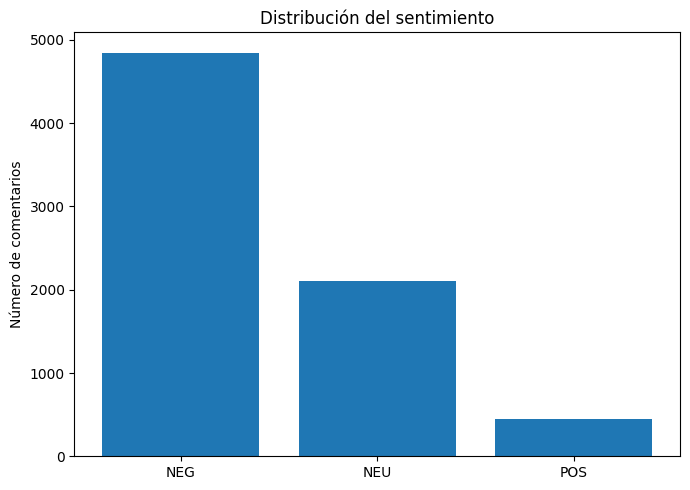

In [65]:
# ============================
# GRÁFICO SENTIMIENTO
# ============================

plt.figure(figsize=(7,5))

plt.bar(
    tabla_sentimiento["sentimiento"],
    tabla_sentimiento["comentarios"]
)

plt.title("Distribución del sentimiento")
plt.xlabel("")
plt.ylabel("Número de comentarios")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "09_sentimiento_general.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
# ============================
# EXPORTAR
# ============================

tabla_sentimiento.to_csv(
    RUTA_TABLAS / "09_sentimiento_general.csv",
    index=False,
    encoding="utf-8-sig"
)

df.to_csv(
    RUTA_PROCESADOS / "forocoches_sentimiento.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Sentimiento exportado correctamente.")

Sentimiento exportado correctamente.


In [67]:
# ============================
# AÑADIR RESULTADOS AL DATAFRAME
# ============================

df["sentimiento"] = [
    resultado["label"]
    for resultado in resultados
]

df["confianza_sentimiento"] = [
    round(resultado["score"], 4)
    for resultado in resultados
]

print("Columnas añadidas correctamente.")

Columnas añadidas correctamente.


In [68]:
# ============================
# DISTRIBUCIÓN GENERAL
# ============================

tabla_sentimiento = (
    df["sentimiento"]
    .value_counts()
    .rename_axis("sentimiento")
    .reset_index(name="comentarios")
)

tabla_sentimiento["porcentaje"] = (
    tabla_sentimiento["comentarios"]
    / tabla_sentimiento["comentarios"].sum()
    * 100
).round(2)

display(tabla_sentimiento)

,sentimiento,comentarios,porcentaje
0,NEG,4849,65.53
1,NEU,2100,28.38
2,POS,451,6.09


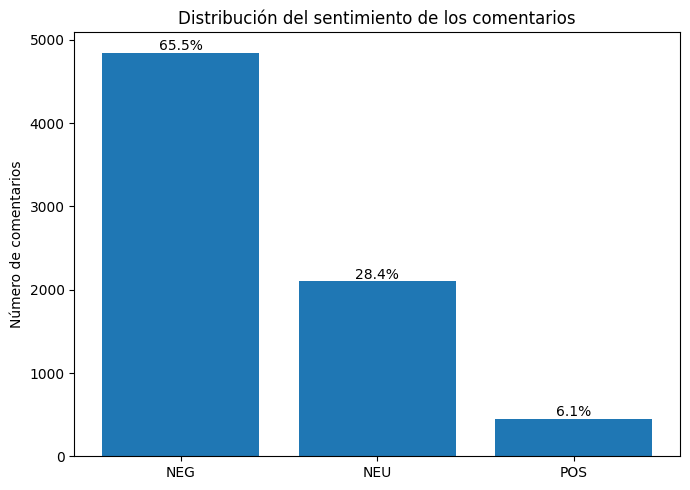

In [69]:
# ============================
# GRÁFICO DE SENTIMIENTO
# ============================

orden = ["NEG", "NEU", "POS"]

tabla_grafico = (
    tabla_sentimiento
    .set_index("sentimiento")
    .reindex(orden)
    .reset_index()
)

plt.figure(figsize=(7,5))

plt.bar(
    tabla_grafico["sentimiento"],
    tabla_grafico["comentarios"]
)

plt.title("Distribución del sentimiento de los comentarios")
plt.xlabel("")
plt.ylabel("Número de comentarios")

for i, fila in tabla_grafico.iterrows():
    plt.text(
        i,
        fila["comentarios"] + 30,
        f'{fila["porcentaje"]:.1f}%',
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "09_distribucion_sentimiento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
# ============================
# EXPORTAR RESULTADOS
# ============================

tabla_sentimiento.to_csv(
    RUTA_TABLAS / "09_distribucion_sentimiento.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Resultados exportados correctamente.")

Resultados exportados correctamente.


In [71]:
# ============================
# SENTIMIENTO VS XENOFOBIA
# ============================

tabla_xeno = pd.crosstab(
    df["nivel_xenofobia_rrss"],
    df["sentimiento"],
    margins=True
)

display(tabla_xeno)

tabla_xeno.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_xenofobia.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS,All
nivel_xenofobia_rrss,,,,
hostilidad_explicita,227,46,3,276
marco_conflictivo,295,42,6,343
neutro,478,95,8,581
sin_mencion,3843,1916,434,6193
violencia_discriminacion,6,1,0,7
All,4849,2100,451,7400


In [72]:
# ============================
# SENTIMIENTO VS LGTBIFOBIA
# ============================

tabla_lgtbi = pd.crosstab(
    df["nivel_lgtbifobia_rrss"],
    df["sentimiento"],
    margins=True
)

display(tabla_lgtbi)

tabla_lgtbi.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_lgtbifobia.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS,All
nivel_lgtbifobia_rrss,,,,
hostilidad_explicita,76,4,1,81
marco_conflictivo,21,2,2,25
neutro,252,56,6,314
sin_mencion,4453,2030,442,6925
violencia_discriminacion,47,8,0,55
All,4849,2100,451,7400


In [73]:
# ============================
# PORCENTAJES
# ============================

tabla_xeno_pct = (
    pd.crosstab(
        df["nivel_xenofobia_rrss"],
        df["sentimiento"],
        normalize="index"
    ) * 100
).round(2)

display(tabla_xeno_pct)

tabla_xeno_pct.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_xenofobia_pct.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS
nivel_xenofobia_rrss,,,
hostilidad_explicita,82.25,16.67,1.09
marco_conflictivo,86.01,12.24,1.75
neutro,82.27,16.35,1.38
sin_mencion,62.05,30.94,7.01
violencia_discriminacion,85.71,14.29,0.00


In [74]:
# ============================
# CHI-CUADRADO Y V DE CRAMÉR
# ============================

from scipy.stats import chi2_contingency
import numpy as np

# Tabla de contingencia (sin porcentajes)
tabla = pd.crosstab(
    df["nivel_xenofobia_rrss"],
    df["sentimiento"]
)

# Test Chi-cuadrado
chi2, p, dof, esperados = chi2_contingency(tabla)

# V de Cramér
n = tabla.to_numpy().sum()
k = min(tabla.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("="*50)
print("CHI-CUADRADO")
print("="*50)
print(f"χ² = {chi2:.3f}")
print(f"p-valor = {p:.8f}")
print(f"Grados de libertad = {dof}")
print(f"V de Cramér = {cramers_v:.3f}")

CHI-CUADRADO
χ² = 211.731
p-valor = 0.00000000
Grados de libertad = 8
V de Cramér = 0.120


In [75]:
# ============================
# INTERPRETACIÓN
# ============================

if p < 0.05:
    print("✅ Existe una asociación estadísticamente significativa.")
else:
    print("❌ No se observa una asociación estadísticamente significativa.")

print()

if cramers_v < 0.10:
    fuerza = "muy débil"
elif cramers_v < 0.30:
    fuerza = "débil"
elif cramers_v < 0.50:
    fuerza = "moderada"
else:
    fuerza = "fuerte"

print(f"Fuerza de la asociación: {fuerza} (V = {cramers_v:.3f})")

✅ Existe una asociación estadísticamente significativa.

Fuerza de la asociación: débil (V = 0.120)


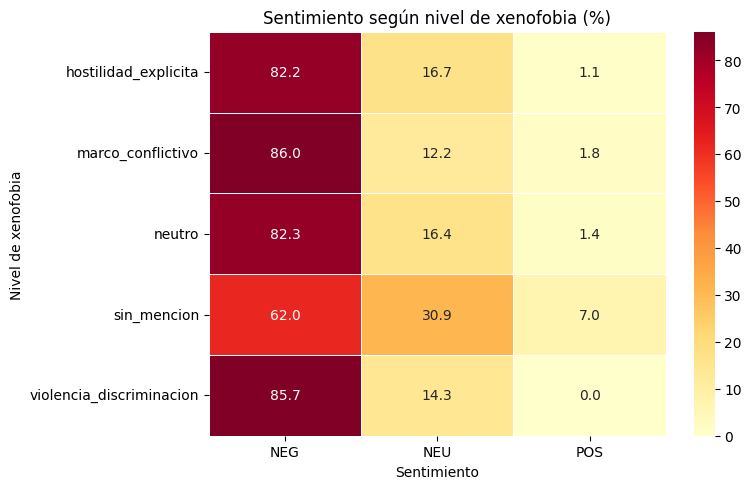

In [76]:
# ============================
# HEATMAP SENTIMIENTO VS XENOFOBIA
# ============================

import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(
    tabla_xeno_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=.5
)

plt.title("Sentimiento según nivel de xenofobia (%)")
plt.xlabel("Sentimiento")
plt.ylabel("Nivel de xenofobia")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "09_heatmap_sentimiento_xenofobia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [77]:
# ============================
# PORCENTAJES LGTBIFOBIA
# ============================

tabla_lgtbi_pct = (
    pd.crosstab(
        df["nivel_lgtbifobia_rrss"],
        df["sentimiento"],
        normalize="index"
    ) * 100
).round(2)

display(tabla_lgtbi_pct)

tabla_lgtbi_pct.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_lgtbifobia_pct.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS
nivel_lgtbifobia_rrss,,,
hostilidad_explicita,93.83,4.94,1.23
marco_conflictivo,84.00,8.00,8.00
neutro,80.25,17.83,1.91
sin_mencion,64.30,29.31,6.38
violencia_discriminacion,85.45,14.55,0.00


In [78]:
# ============================
# CHI-CUADRADO LGTBIFOBIA
# ============================

tabla = pd.crosstab(
    df["nivel_lgtbifobia_rrss"],
    df["sentimiento"]
)

chi2, p, dof, esperados = chi2_contingency(tabla)

n = tabla.to_numpy().sum()
k = min(tabla.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("="*50)
print("CHI-CUADRADO LGTBIFOBIA")
print("="*50)
print(f"χ² = {chi2:.3f}")
print(f"p-valor = {p:.8f}")
print(f"Grados de libertad = {dof}")
print(f"V de Cramér = {cramers_v:.3f}")

if p < 0.05:
    print("\n✅ Existe una asociación estadísticamente significativa.")
else:
    print("\n❌ No existe una asociación estadísticamente significativa.")

if cramers_v < 0.10:
    fuerza = "muy débil"
elif cramers_v < 0.30:
    fuerza = "débil"
elif cramers_v < 0.50:
    fuerza = "moderada"
else:
    fuerza = "fuerte"

print(f"Fuerza de la asociación: {fuerza}")

CHI-CUADRADO LGTBIFOBIA
χ² = 80.601
p-valor = 0.00000000
Grados de libertad = 8
V de Cramér = 0.074

✅ Existe una asociación estadísticamente significativa.
Fuerza de la asociación: muy débil


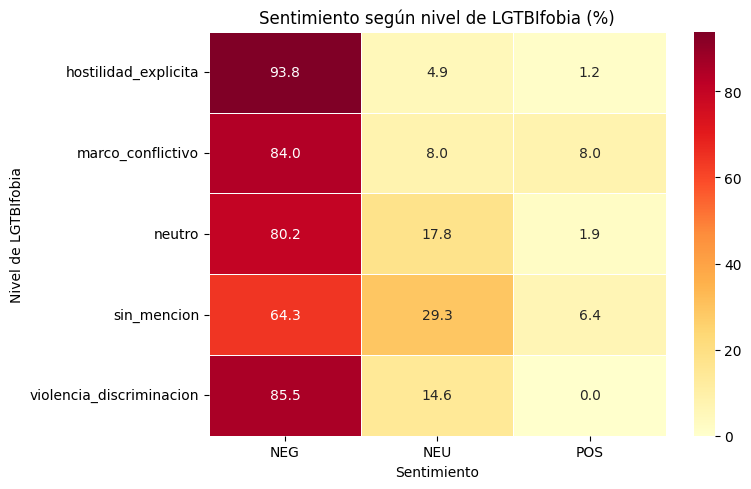

In [79]:
# ============================
# HEATMAP LGTBIFOBIA
# ============================

plt.figure(figsize=(8,5))

sns.heatmap(
    tabla_lgtbi_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=.5
)

plt.title("Sentimiento según nivel de LGTBIfobia (%)")
plt.xlabel("Sentimiento")
plt.ylabel("Nivel de LGTBIfobia")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "09_heatmap_sentimiento_lgtbifobia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [80]:
# ============================
# XENOFOBIA SIN "SIN_MENCION"
# ============================

df_xeno = df[
    df["nivel_xenofobia_rrss"] != "sin_mencion"
].copy()

tabla_xeno_filtrado = pd.crosstab(
    df_xeno["nivel_xenofobia_rrss"],
    df_xeno["sentimiento"],
    normalize="index"
) * 100

tabla_xeno_filtrado = tabla_xeno_filtrado.round(2)

display(tabla_xeno_filtrado)

sentimiento,NEG,NEU,POS
nivel_xenofobia_rrss,,,
hostilidad_explicita,82.25,16.67,1.09
marco_conflictivo,86.01,12.24,1.75
neutro,82.27,16.35,1.38
violencia_discriminacion,85.71,14.29,0.00


In [81]:
# ============================
# CHI-CUADRADO XENOFOBIA
# (SIN "SIN_MENCION")
# ============================

tabla = pd.crosstab(
    df_xeno["nivel_xenofobia_rrss"],
    df_xeno["sentimiento"]
)

chi2, p, dof, esperados = chi2_contingency(tabla)

n = tabla.to_numpy().sum()
k = min(tabla.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("=" * 50)
print("XENOFOBIA (SIN 'SIN_MENCION')")
print("=" * 50)

print(f"χ² = {chi2:.3f}")
print(f"p = {p:.8f}")
print(f"V de Cramér = {cramers_v:.3f}")

if p < 0.05:
    print("✅ Asociación significativa")
else:
    print("❌ Asociación no significativa")

XENOFOBIA (SIN 'SIN_MENCION')
χ² = 3.866
p = 0.69480141
V de Cramér = 0.040
❌ Asociación no significativa


In [82]:
# ============================
# LGTBIFOBIA SIN "SIN_MENCION"
# ============================

df_lgtbi = df[
    df["nivel_lgtbifobia_rrss"] != "sin_mencion"
].copy()

tabla_lgtbi_filtrado = pd.crosstab(
    df_lgtbi["nivel_lgtbifobia_rrss"],
    df_lgtbi["sentimiento"],
    normalize="index"
) * 100

tabla_lgtbi_filtrado = tabla_lgtbi_filtrado.round(2)

display(tabla_lgtbi_filtrado)

sentimiento,NEG,NEU,POS
nivel_lgtbifobia_rrss,,,
hostilidad_explicita,93.83,4.94,1.23
marco_conflictivo,84.00,8.00,8.00
neutro,80.25,17.83,1.91
violencia_discriminacion,85.45,14.55,0.00


In [83]:
# ============================
# CHI-CUADRADO LGTBIFOBIA
# (SIN "SIN_MENCION")
# ============================

tabla = pd.crosstab(
    df_lgtbi["nivel_lgtbifobia_rrss"],
    df_lgtbi["sentimiento"]
)

chi2, p, dof, esperados = chi2_contingency(tabla)

n = tabla.to_numpy().sum()
k = min(tabla.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("=" * 50)
print("LGTBIFOBIA (SIN 'SIN_MENCION')")
print("=" * 50)

print(f"χ² = {chi2:.3f}")
print(f"p = {p:.8f}")
print(f"V de Cramér = {cramers_v:.3f}")

if p < 0.05:
    print("✅ Asociación significativa")
else:
    print("❌ Asociación no significativa")

LGTBIFOBIA (SIN 'SIN_MENCION')
χ² = 15.698
p = 0.01547179
V de Cramér = 0.129
✅ Asociación significativa


In [84]:
# ============================
# RESUMEN DE PRUEBAS ESTADÍSTICAS
# ============================

def calcular_asociacion(dataframe, variable, nombre):
    
    tabla = pd.crosstab(
        dataframe[variable],
        dataframe["sentimiento"]
    )

    chi2, p, dof, esperados = chi2_contingency(tabla)

    n = tabla.to_numpy().sum()
    k = min(tabla.shape)

    v_cramer = np.sqrt(
        chi2 / (n * (k - 1))
    )

    if v_cramer < 0.10:
        fuerza = "muy débil"
    elif v_cramer < 0.30:
        fuerza = "débil"
    elif v_cramer < 0.50:
        fuerza = "moderada"
    else:
        fuerza = "fuerte"

    return {
        "comparacion": nombre,
        "n_comentarios": n,
        "chi2": round(chi2, 3),
        "p_valor": p,
        "grados_libertad": dof,
        "v_cramer": round(v_cramer, 3),
        "significativa": "Sí" if p < 0.05 else "No",
        "fuerza_asociacion": fuerza
    }


resultados_estadisticos = [
    calcular_asociacion(
        df,
        "nivel_xenofobia_rrss",
        "Sentimiento vs Xenofobia"
    ),
    
    calcular_asociacion(
        df_xeno,
        "nivel_xenofobia_rrss",
        "Sentimiento vs Xenofobia (sin sin_mencion)"
    ),
    
    calcular_asociacion(
        df,
        "nivel_lgtbifobia_rrss",
        "Sentimiento vs LGTBIfobia"
    ),
    
    calcular_asociacion(
        df_lgtbi,
        "nivel_lgtbifobia_rrss",
        "Sentimiento vs LGTBIfobia (sin sin_mencion)"
    )
]

estadisticos = pd.DataFrame(resultados_estadisticos)

display(estadisticos)

,comparacion,n_comentarios,chi2,p_valor,grados_libertad,v_cramer,significativa,fuerza_asociacion
0,Sentimiento vs Xenofobia,7400,211.731,2.145924e-41,8,0.120,Sí,débil
1,Sentimiento vs Xenofobia (sin sin_mencion),1207,3.866,6.948014e-01,6,0.040,No,muy débil
2,Sentimiento vs LGTBIfobia,7400,80.601,3.700859e-14,8,0.074,Sí,muy débil
3,Sentimiento vs LGTBIfobia (sin sin_mencion),475,15.698,1.547179e-02,6,0.129,Sí,débil


In [85]:
estadisticos.to_csv(
    RUTA_TABLAS / "09_pruebas_estadisticas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Pruebas estadísticas exportadas correctamente.")

Pruebas estadísticas exportadas correctamente.


### Bloque 6. Biogramas 

In [86]:
# ============================
# BIGRAMAS
# ============================

from sklearn.feature_extraction.text import CountVectorizer

In [87]:
# ============================
# GENERAR BIGRAMAS
# ============================

vectorizador = CountVectorizer(
    ngram_range=(2, 2),
    stop_words=list(stopwords_sin_tildes),
    min_df=5
)

matriz = vectorizador.fit_transform(
    df["texto_limpio"].fillna("")
)

frecuencias = matriz.sum(axis=0).A1

bigramas = pd.DataFrame({
    "bigrama": vectorizador.get_feature_names_out(),
    "frecuencia": frecuencias
})

bigramas = (
    bigramas
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

bigramas_excluir = {
    "he dicho",
    "he visto",
    "ni siquiera",
    "10 años",
    "20 años",
    "está pasando",
    "esperaba más",
    "cualquier persona",
    "mucha gente",
    "estoy favor",
    "estoy acuerdo",
    "etc etc",
    "bla bla",
    "he leído",
    "hoy día",
    "pillo sitio"
}

bigramas = bigramas[
    ~bigramas["bigrama"].isin(bigramas_excluir)
].reset_index(drop=True)

bigramas["bigrama"] = bigramas["bigrama"].replace({
    "puto pais": "puto país"
})

bigramas = (
    bigramas
    .groupby("bigrama", as_index=False)["frecuencia"]
    .sum()
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

display(bigramas.head(30))

,bigrama,frecuencia
0,tomar culo,87
1,hijo puta,58
2,puta madre,44
3,puto país,42
4,inmigración ilegal,35
5,per capita,34
6,cago puta,32
7,hijos puta,31
8,pib per,29
9,nuestro país,28


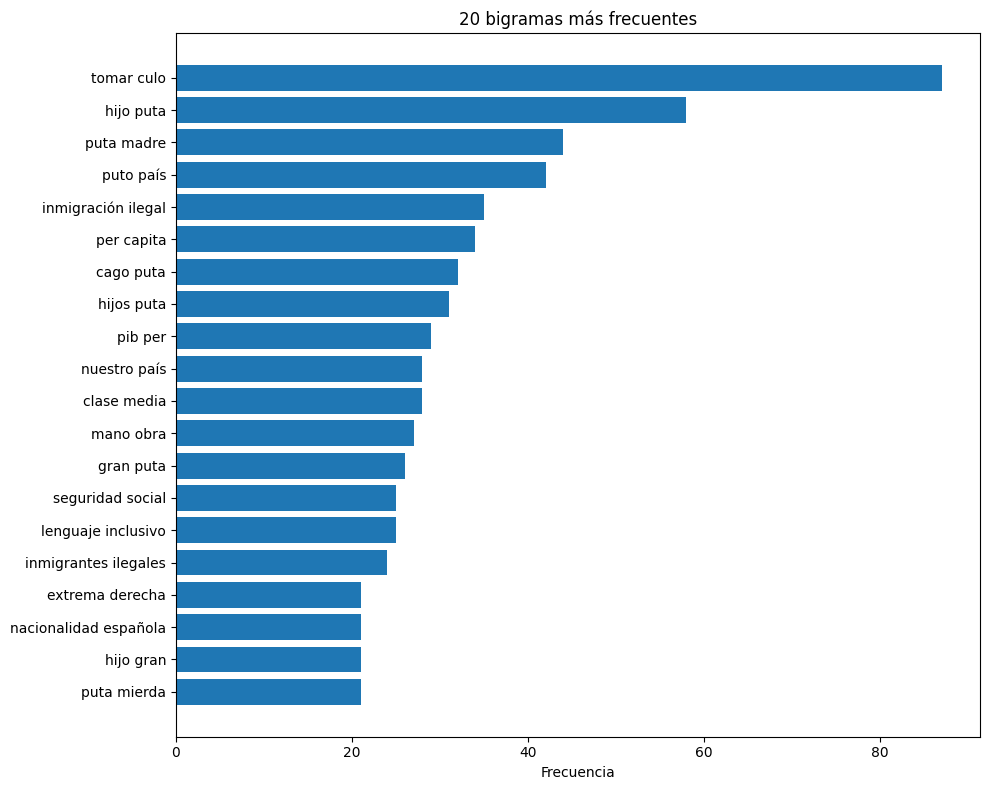

In [88]:
# ============================
# TOP 20 BIGRAMAS
# ============================

top_bigramas = bigramas.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_bigramas["bigrama"][::-1],
    top_bigramas["frecuencia"][::-1]
)

plt.title("20 bigramas más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "10_bigramas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [89]:
bigramas.to_csv(
    RUTA_TABLAS / "10_bigramas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Bigramas exportados correctamente.")

Bigramas exportados correctamente.


### Bloque 7. Trigramas

In [90]:
# ============================
# TRIGRAMAS
# ============================

vectorizador = CountVectorizer(
    ngram_range=(3, 3),
    stop_words=list(stopwords_sin_tildes),
    min_df=3
)

matriz = vectorizador.fit_transform(
    df["texto_limpio"].fillna("")
)

frecuencias = matriz.sum(axis=0).A1

trigramas = pd.DataFrame({
    "trigrama": vectorizador.get_feature_names_out(),
    "frecuencia": frecuencias
})

trigramas = (
    trigramas
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

# ============================
# ELIMINAR TRIGRAMAS POCO INFORMATIVOS
# ============================

trigramas_excluir = {
    "bla bla bla",
    "esperaba más españa",
    "estoy totalmente acuerdo",
    "pillo sitio leer",
    "suficiente internet hoy",
    "ugt he leido",
    "está lista ignorados",
    "mensaje está oculto",
    "informe elaborado ugt"
}

trigramas = (
    trigramas[
        ~trigramas["trigrama"].isin(trigramas_excluir)
    ]
    .reset_index(drop=True)
)

display(trigramas.head(30))

,trigrama,frecuencia
0,pib per capita,28
1,hijo gran puta,19
2,cago puta madre,13
3,mano obra barata,12
4,menudo hijo puta,10
5,dar palo agua,9
6,hijos gran puta,7
7,hijo mil putas,6
8,dos dedos frente,6
9,abdsalam haj taher,6


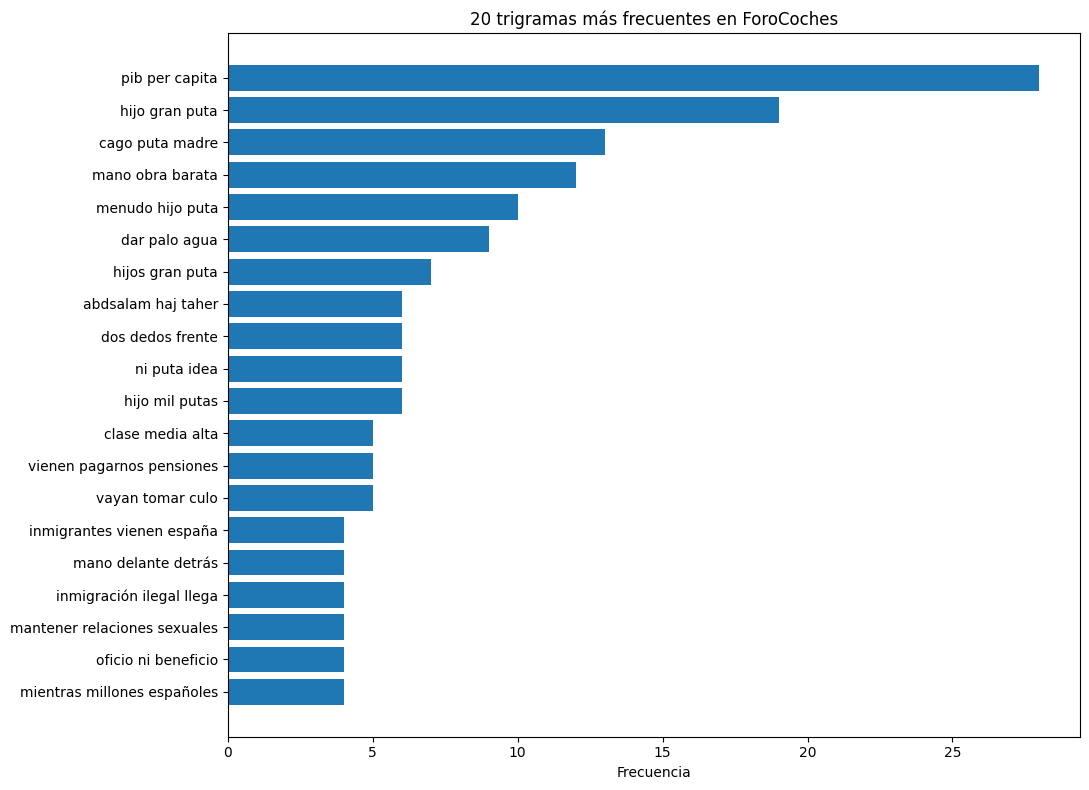

In [91]:
top_trigramas = trigramas.head(20).sort_values(
    "frecuencia",
    ascending=True
)

plt.figure(figsize=(11, 8))

plt.barh(
    top_trigramas["trigrama"],
    top_trigramas["frecuencia"]
)

plt.title("20 trigramas más frecuentes en ForoCoches")
plt.xlabel("Frecuencia")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "11_top_20_trigramas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [92]:
trigramas.to_csv(
    RUTA_TABLAS / "11_trigramas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Trigramas exportados correctamente.")

Trigramas exportados correctamente.


### Bloque 8. BERTopic

In [93]:
# ============================
# INSTALAR BERTopic
# ============================

%pip install bertopic umap-learn hdbscan sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [94]:
# ============================
# IMPORTAR LIBRERÍAS
# ============================

from bertopic import BERTopic

from sentence_transformers import SentenceTransformer

from sklearn.feature_extraction.text import CountVectorizer

from umap import UMAP

from hdbscan import HDBSCAN

In [99]:
# ============================
# CONFIGURACIÓN BERTopic
# ============================

embedding_model = SentenceTransformer(
    "paraphrase-multilingual-mpnet-base-v2"
)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,   # antes 25
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# ============================
# STOPWORDS EXTRA
# ============================

stopwords_extra = {
    "más", "ni", "qué", "aquí", "así",
    "también", "solo", "si", "ya",
    "pues", "hacer", "dice", "dijo","así","también","solo","ya",
    "ser", "estar", "va", "hay", "más","ni","qué","aquí",
    "ser","estar","hacer","dice","dijo","hay","va",
    "puede","pueden","puedo","hacer","hace","hacerlo",
    "persona","personas","gente","años","vez"
}

stopwords_sin_tildes.update(
    quitar_tildes(p) for p in stopwords_extra
)

vectorizer_model = CountVectorizer(
    stop_words=list(stopwords_sin_tildes),
    ngram_range=(1,3),
    min_df=5
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="multilingual",
    calculate_probabilities=False,
    verbose=True
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9941.95it/s]


In [100]:
# ============================
# ENTRENAR BERTopic
# ============================

documentos = (
    df["texto_limpio"]
    .fillna("")
    .tolist()
)

topics, probabilities = topic_model.fit_transform(documentos)

2026-07-19 19:07:15,038 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 232/232 [02:00<00:00,  1.93it/s]
2026-07-19 19:09:15,349 - BERTopic - Embedding - Completed ✓
2026-07-19 19:09:15,350 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-19 19:09:22,386 - BERTopic - Dimensionality - Completed ✓
2026-07-19 19:09:22,387 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-19 19:09:22,524 - BERTopic - Cluster - Completed ✓
2026-07-19 19:09:22,526 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-19 19:09:22,766 - BERTopic - Representation - Completed ✓


In [101]:
# ============================
# INFORMACIÓN DE LOS TEMAS
# ============================

info_temas = topic_model.get_topic_info()

display(info_temas.head(20))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3177,-1_inmigrantes_más_españa_país,"[inmigrantes, más, españa, país, españoles, aquí, qué, inmigración, europa, millones]","[desmontando con datos la gran mentira que nos venden la mayoría de medios de comunicación que afirman “no hay ningún estudio, dato o estadística ..."
1,0,471,0_pp_votar_políticos_voto,"[pp, votar, políticos, voto, izquierda, vox, partidos, psoe, podemos, derecha]","[pero vamos a ver, que coño dices? yo nunca he votado al pp. nunca. siempre a upyd y este ultimo año a ciudadanos la primera vez, la segunda no vo..."
2,1,236,1_puta_cago_tomar culo_culo,"[puta, cago, tomar culo, culo, tomar, cago puta, hijo, hijo puta, puta madre, mierda]","[que se vaya a tomar por el culo, a tomar por culo los refujetas, a tomar por culo., y si se va a tomar por culo?]"
3,2,135,2_noticias_noticia_medios_twitter,"[noticias, noticia, medios, twitter, ignorante, realidad, mentira, creen, foro, forocoches]","[claro, claro, ya se ve por dónde vas. ¿qué pasa, que si no lo publica el país no es verdad, mugroso? modo forocochero off. ahora, la realidad: se..."
4,3,133,3_gays_homosexuales_homosexual_matrimonio,"[gays, homosexuales, homosexual, matrimonio, homo, homófobo, partido, lobby, colectivo, homofobia]","[eso no es pasarse de tópicos gays?, a ver, acomplejados y gays reprimidos., en 2005, año en el que se aprobó el matrimonio homosexual, mariano ra..."
5,4,130,4_ugt_sitio_fuente_ay,"[ugt, sitio, fuente, ay, pole, mariquita, muerto, xd, gentuza, op]","[ugt máxima fiabilidad, ugt-qw., fuente: de marisco >ugt]"
6,5,111,5_pais_familia_puto pais_niña,"[pais, familia, puto pais, niña, padres, hijos, feliz, puto, vuelta, hija]","[las chorradas que una tiene que leer. uno, el dr money siempre fue un cabrón manipulador. dos, el asunto de david reimer viene de un error médico..."
7,6,104,6_inmigración_delincuencia_ilegal_delincuentes,"[inmigración, delincuencia, ilegal, delincuentes, problema, inmigrantes, fronteras, inmigracion, inmigrante, barrios]","[es incorrecto, el problema de la delincuencia no se deriva de la inmigración en sí, sino del tipo de inmigrante., hola, oigo muchas quejas entre ..."
8,7,103,7_alemania_pire_merkel_amigos,"[alemania, pire, merkel, amigos, irse, ayudas, puta, pais, él, casa]","[pues mejor, que se vaya a emirato de alemania, qque se vaya a alemania, esto demuestra que en alemania son unos o parguelas]"
9,8,83,8_barco_ong_costa_tráfico,"[barco, ong, costa, tráfico, mafia, mar, patera, seguro, ongs, dejan]",[la policía de fronteras italiana ha grabado como los inmigrantes vienen en barco y cuando este ve que el barco de open arms esta cerca los coloca...


In [102]:
# ============================
# EXPORTAR INFORMACIÓN DE TEMAS
# ============================

info_temas.to_csv(
    RUTA_TABLAS / "12_bertopic_temas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tabla de temas exportada correctamente.")

Tabla de temas exportada correctamente.


In [103]:
# ============================
# ASIGNAR TEMA A CADA COMENTARIO
# ============================

df["topic_bertopic"] = topics

df[[
    "texto_limpio",
    "topic_bertopic"
]].head()

,texto_limpio,topic_bertopic
0,"es lo que están acostumbrados en sus países, si no mirad lo que pasa en guatemala, el salvador, honduras... y países musulmanes, con guerras civil...",19
1,"ya te lo dice esta pole, cada vecino en su parcela",24
2,lo que hay que hacer es dar una patada en el culo a todo invasor parásito que pise europa.,-1
3,menudo ladrillo a estas horas,-1
4,la segunda y cuarta opción son lo mismo.,10


In [ ]:
df.to_csv(
    RUTA_PROCESADOS
    / "forocoches_comentarios_nlp.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Comentarios con tema BERTopic exportados correctamente.")

Comentarios con tema BERTopic exportados correctamente.


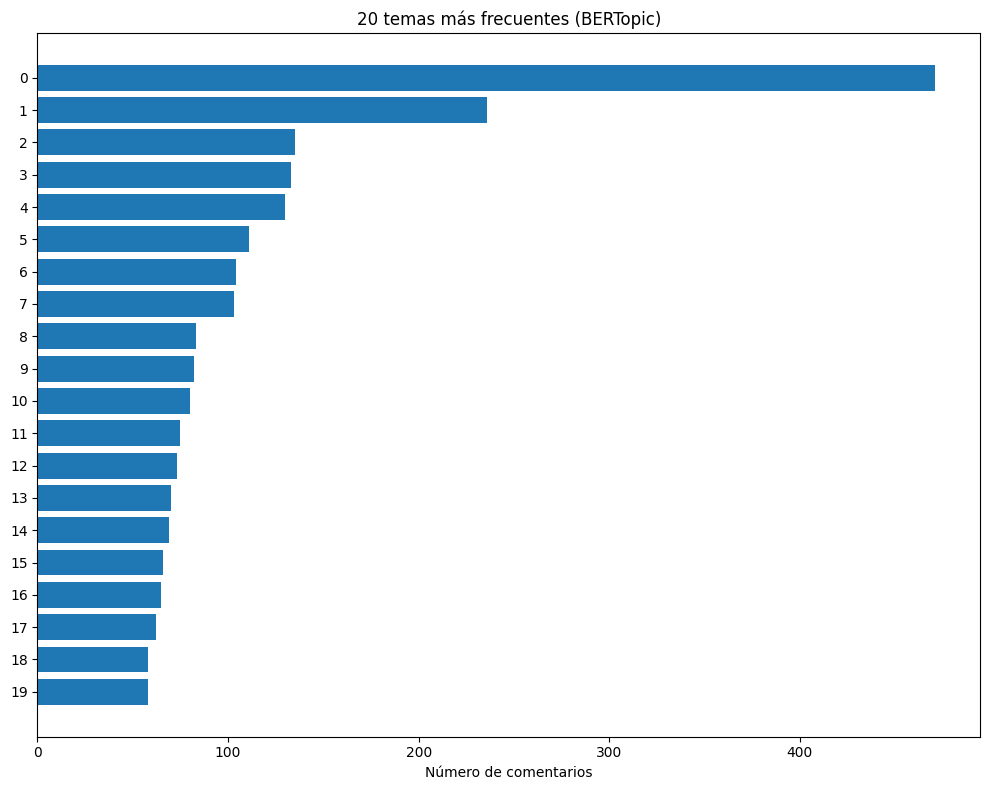

In [108]:
top20 = (
    info_temas[info_temas["Topic"] != -1]
    .sort_values("Count", ascending=True)
    .tail(20)
)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Topic"].astype(str),
    top20["Count"]
)

plt.title("20 temas más frecuentes (BERTopic)")
plt.xlabel("Número de comentarios")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "12_top20_temas_bertopic.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Bloque 9: Síntesis y conclusiones del análisis NLP

# 10. Síntesis del análisis NLP

En este apartado se integran los resultados obtenidos mediante las diferentes técnicas de procesamiento del lenguaje natural aplicadas a los comentarios de ForoCoches.

Se resumen los principales patrones lingüísticos, emocionales y temáticos detectados, proporcionando una visión global del discurso presente en el corpus analizado.

In [109]:
# ============================
# RESUMEN DEL ANÁLISIS NLP
# ============================

print("=" * 60)
print("RESUMEN DEL ANÁLISIS NLP")
print("=" * 60)

print(f"Comentarios analizados: {len(df):,}")

print(f"\nTemas BERTopic detectados: {(info_temas['Topic'] != -1).sum()}")

print(f"Comentarios sin asignar (-1): {(df['topic_bertopic'] == -1).sum():,}")

print(f"\nPalabras únicas: {df['texto_limpio'].str.split().explode().nunique():,}")

print("=" * 60)

RESUMEN DEL ANÁLISIS NLP
Comentarios analizados: 7,400

Temas BERTopic detectados: 101
Comentarios sin asignar (-1): 3,177

Palabras únicas: 32,652


In [110]:
# ============================
# PRINCIPALES HALLAZGOS
# ============================

hallazgos = [
    ["Frecuencia léxica",
     "Predominio de términos relacionados con inmigración, política e identidad."],

    ["Sentimiento",
     "Predominio de comentarios con polaridad negativa o muy polarizada."],

    ["Discurso de odio",
     "Presencia recurrente de vocabulario despectivo e insultos."],

    ["Bigramas",
     "Asociaciones frecuentes entre inmigración, delincuencia, ayudas y fronteras."],

    ["Trigramas",
     "Expresiones repetidas que reflejan marcos narrativos y consignas del debate."],

    ["BERTopic",
     "Identificación automática de temas relacionados con inmigración, política, islam, LGTBI, delincuencia, ayudas sociales y educación."]
]

df_hallazgos = pd.DataFrame(
    hallazgos,
    columns=["Análisis", "Principal resultado"]
)

display(df_hallazgos)

,Análisis,Principal resultado
0,Frecuencia léxica,"Predominio de términos relacionados con inmigración, política e identidad."
1,Sentimiento,Predominio de comentarios con polaridad negativa o muy polarizada.
2,Discurso de odio,Presencia recurrente de vocabulario despectivo e insultos.
3,Bigramas,"Asociaciones frecuentes entre inmigración, delincuencia, ayudas y fronteras."
4,Trigramas,Expresiones repetidas que reflejan marcos narrativos y consignas del debate.
5,BERTopic,"Identificación automática de temas relacionados con inmigración, política, islam, LGTBI, delincuencia, ayudas sociales y educación."


In [111]:
# ============================
# EXPORTAR SÍNTESIS
# ============================

df_hallazgos.to_csv(
    RUTA_TABLAS / "14_resumen_nlp.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Resumen NLP exportado correctamente.")

Resumen NLP exportado correctamente.
